# Segmentação RFM para Marketing

Este notebook realiza a segmentação de clientes utilizando a análise RFM (Recência, Frequência, Monetário) no dataset Online Retail II.

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt
import os
import config

## 1. Carregar o dataset

In [13]:
# Carregar o dataset
try:
    file_path = os.path.join(config.PATH, 'online_retail_II.csv')
    df = pd.read_csv(file_path)
    print("Dataset carregado com sucesso!")
    display(df.head())
except FileNotFoundError:
    print(f"Arquivo não encontrado em: {file_path}")

Dataset carregado com sucesso!


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


## 2. Limpeza dos Dados

In [14]:
# Verificar nulos
print("Nulos antes da limpeza:")
print(df.isnull().sum())

# Remover nulos (especialmente Customer ID que é essencial para RFM)
df = df.dropna(subset=['Customer ID'])

# Remover cancelamentos (Invoice contendo 'C')
df = df[~df['Invoice'].astype(str).str.contains('C')]

# Remover valores negativos ou zerados em Quantity e Price
df = df[(df['Quantity'] > 0) & (df['Price'] > 0)]

# Converter InvoiceDate para datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

print("\nDimensões após limpeza:", df.shape)

Nulos antes da limpeza:
Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

Dimensões após limpeza: (805549, 8)


## 3. Feature Engineering

In [ ]:
# Calcular Sales (Receita)
df['Sales'] = df['Quantity'] * df['Price']
df.head()

In [ ]:
# Transformar InvoiceDate em data
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
# Converter CustomerID em inteiro
df['CustomerID'] = df['CustomerID'].astype(int)

## 4. Análise Exploratória de Dados (EDA)

C:\Users\jemeo\AppData\Local\Temp\ipykernel_26580\1813012333.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_countries.values, y=top_countries.index, palette='viridis')


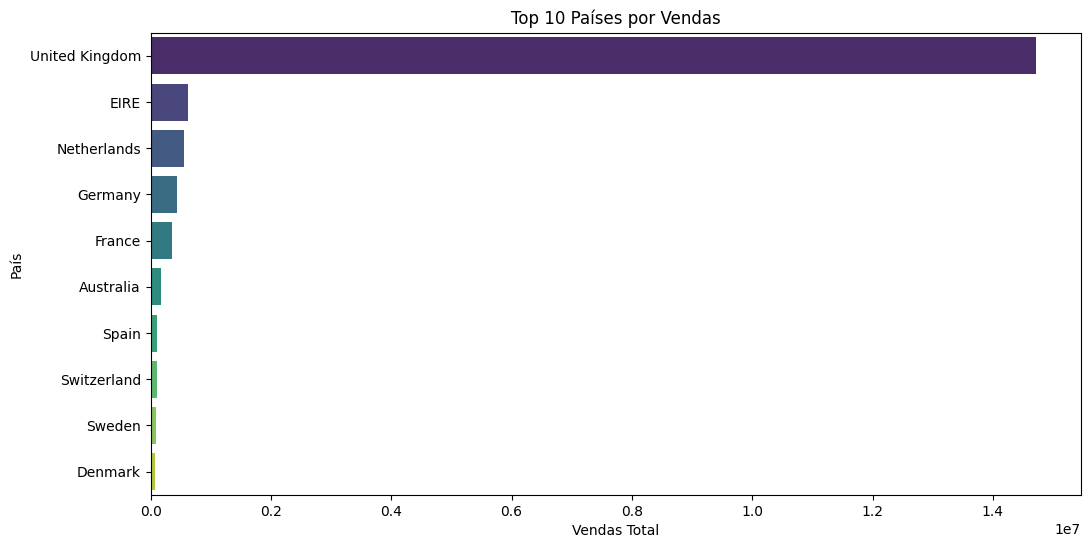

In [24]:
# Top 10 Países com maior valor em vendas
top_countries = df.groupby('Country')['Sales'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(12, 6))
sns.barplot(x=top_countries.values, y=top_countries.index, palette='viridis')
plt.title('Top 10 Países por Vendas')
plt.xlabel('Vendas Total')
plt.ylabel('País')
plt.show()

C:\Users\jemeo\AppData\Local\Temp\ipykernel_26580\743602104.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_products_qty.values, y=top_products_qty.index, palette='magma')


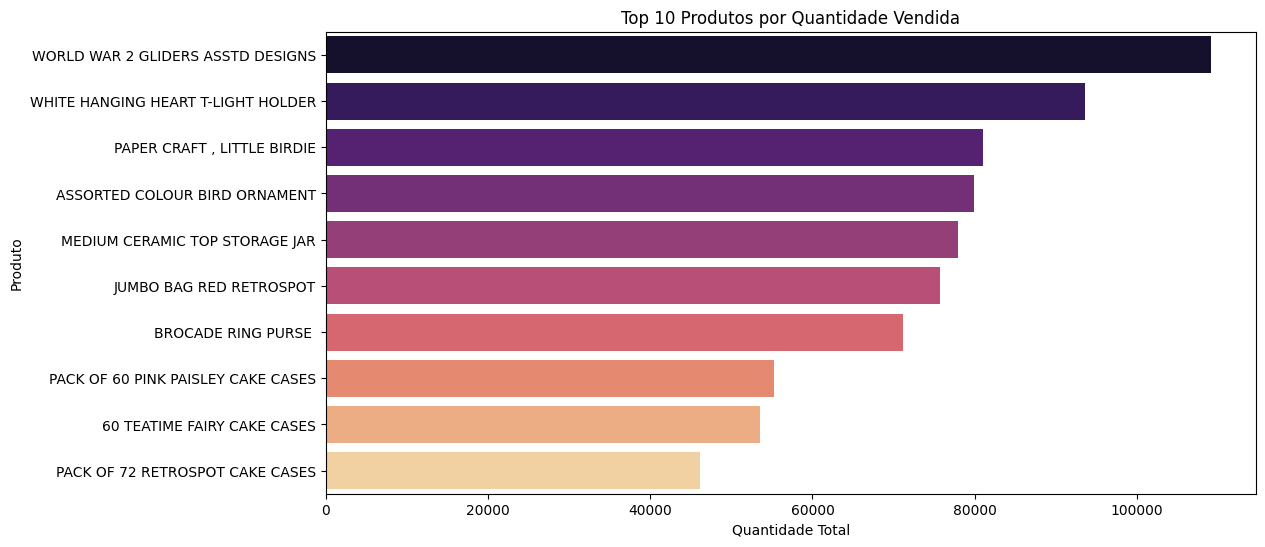

In [25]:
# Top 10 Produtos mais vendidos (Quantidade)
top_products_qty = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(12, 6))
sns.barplot(x=top_products_qty.values, y=top_products_qty.index, palette='magma')
plt.title('Top 10 Produtos por Quantidade Vendida')
plt.xlabel('Quantidade Total')
plt.ylabel('Produto')
plt.show()

C:\Users\jemeo\AppData\Local\Temp\ipykernel_26580\4182546289.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_products_sales.values, y=top_products_sales.index, palette='coolwarm')


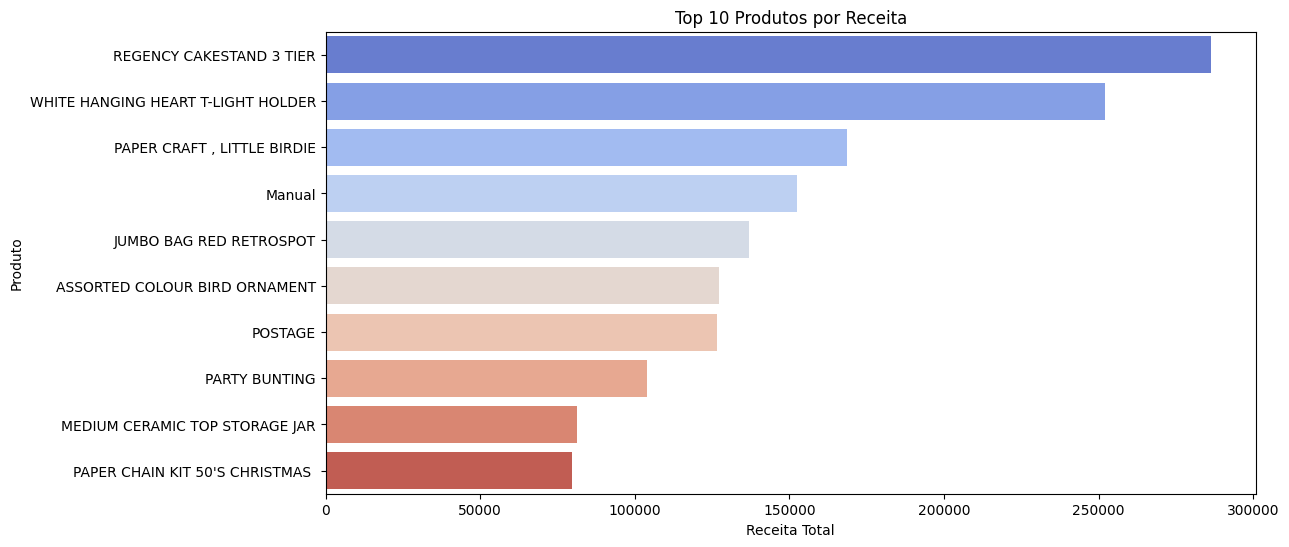

In [26]:
# Top 10 Produtos com maior receita (Sales)
top_products_sales = df.groupby('Description')['Sales'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(12, 6))
sns.barplot(x=top_products_sales.values, y=top_products_sales.index, palette='coolwarm')
plt.title('Top 10 Produtos por Receita')
plt.xlabel('Receita Total')
plt.ylabel('Produto')
plt.show()

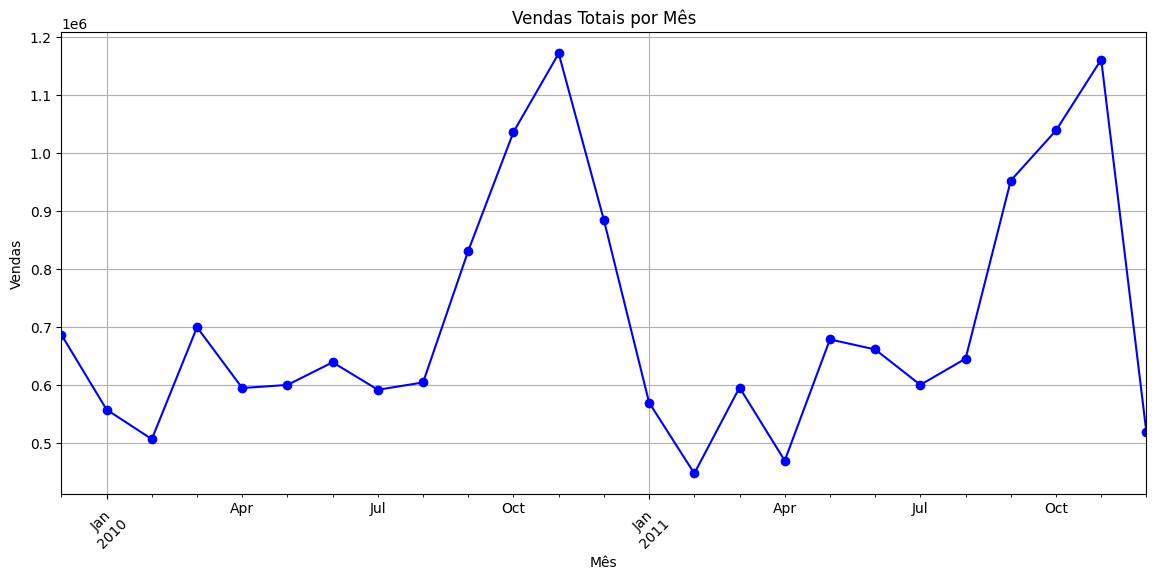

In [27]:
# Vendas por Mês (Ano-Mês)
df['MonthYear'] = df['InvoiceDate'].dt.to_period('M')
sales_by_month = df.groupby('MonthYear')['Sales'].sum()

plt.figure(figsize=(14, 6))
sales_by_month.plot(kind='line', marker='o', color='b')
plt.title('Vendas Totais por Mês')
plt.xlabel('Mês')
plt.ylabel('Vendas')
plt.grid(True)
plt.xticks(rotation=45)
plt.show()

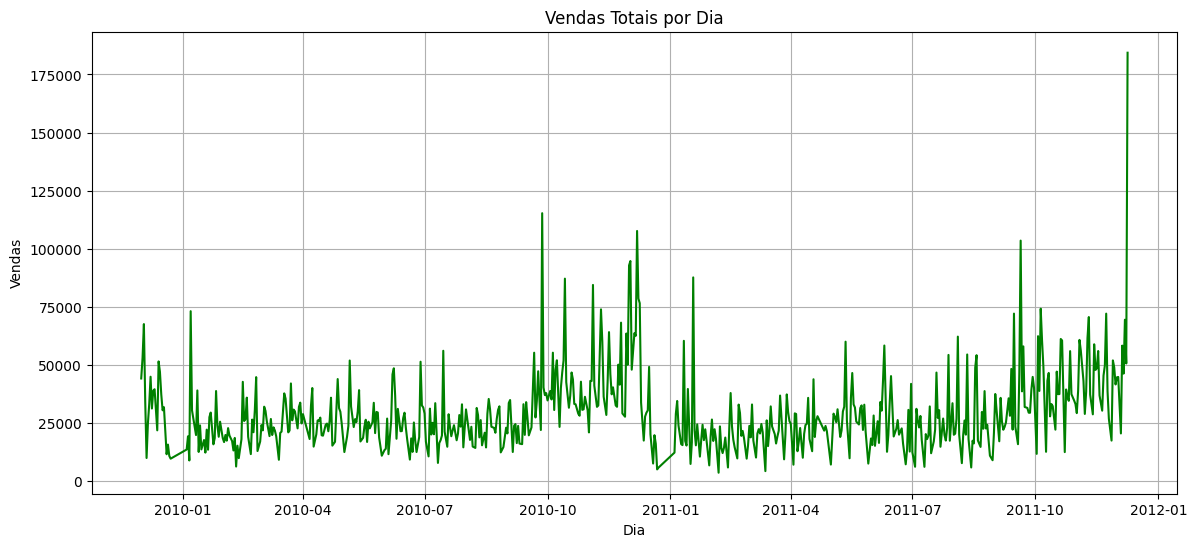

In [28]:
# Vendas por Dia
sales_by_day = df.groupby(df['InvoiceDate'].dt.date)['Sales'].sum()

plt.figure(figsize=(14, 6))
sales_by_day.plot(kind='line', color='g')
plt.title('Vendas Totais por Dia')
plt.xlabel('Dia')
plt.ylabel('Vendas')
plt.grid(True)
plt.show()

C:\Users\jemeo\AppData\Local\Temp\ipykernel_26580\1363054589.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sales_by_weekday.index, y=sales_by_weekday.values, palette='autumn')


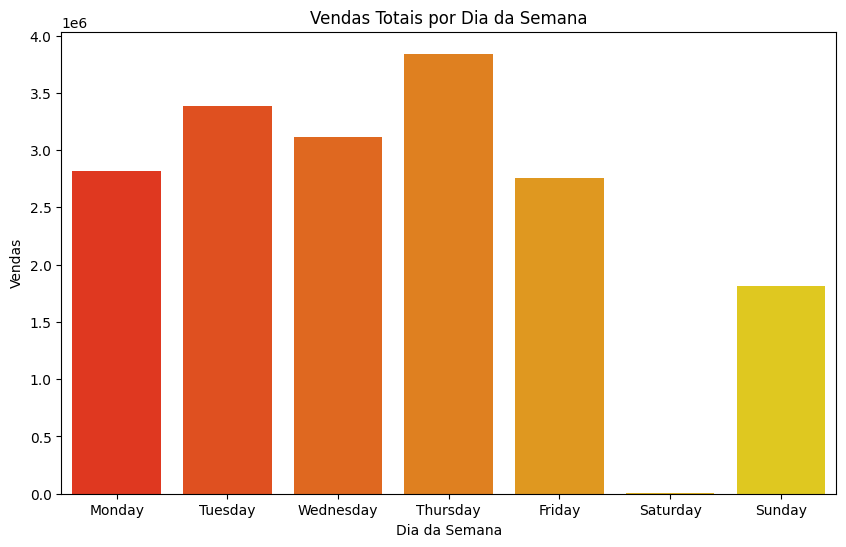

In [29]:
# Vendas por Dia da Semana
df['DayOfWeek'] = df['InvoiceDate'].dt.day_name()
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
sales_by_weekday = df.groupby('DayOfWeek')['Sales'].sum().reindex(days_order)

plt.figure(figsize=(10, 6))
sns.barplot(x=sales_by_weekday.index, y=sales_by_weekday.values, palette='autumn')
plt.title('Vendas Totais por Dia da Semana')
plt.xlabel('Dia da Semana')
plt.ylabel('Vendas')
plt.show()

## 5. Gerar Dataframe RFM

In [ ]:
# Definir data de referência (dia seguinte à última compra no dataset)
ref_date = df['InvoiceDate'].max() + dt.timedelta(days=1)

# Calcular Recência, Frequência e Monetário
df_rfm = df.groupby('Customer ID').agg({
    'InvoiceDate': lambda x: (ref_date - x.max()).days,
    'Invoice': 'nunique',
    'Sales': 'sum'
})

# Renomear colunas
df_rfm.rename(columns={
    'InvoiceDate': 'Recency',
    'Invoice': 'Frequency',
    'Sales': 'Monetary'
}, inplace=True)

df_rfm.head()

## FASE 3: Modelagem (K-Means)
*(A ser implementado)*

## FASE 4: Valor de Negócio
*(A ser implementado)*